In [1]:
# Fruit & Vegetable Freshness
# Ayaz Azimov
# 23291816

import time
import cv2
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATA_PATH = Path('/content/drive/MyDrive/My_Project_Data')

Mounted at /content/drive


In [2]:
def load_data():
    images, labels = [], []
    img_size = 100
    print(f"Loading images at {img_size}x{img_size} resolution")

    categories = {
        DATA_PATH / 'Fresh_Images': 0,
        DATA_PATH / 'Rotten_Images': 1
    }

    for folder, label in categories.items():

        for filepath in folder.iterdir():
            img = cv2.imread(str(filepath))
            if img is not None:
                img = cv2.resize(img, (img_size, img_size))
                images.append(img.astype('float32') / 255.0)
                labels.append(label)

    X, y = np.array(images), np.array(labels)
    print(f"Loaded a total of {len(X)} images.\n")

    return train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [3]:
def train_svm(X_train, X_test, y_train, y_test):
    print("Training SVM model...")
    start_time = time.time()

    train_images_1d = X_train.reshape(len(X_train), -1)
    test_images_1d = X_test.reshape(len(X_test), -1)

    model = SGDClassifier(loss='hinge', max_iter=1000, tol=1e-3, random_state=42, n_jobs=-1)
    model.fit(train_images_1d, y_train)

    acc = accuracy_score(y_test, model.predict(test_images_1d))
    duration = time.time() - start_time

    print(f"SVM Accuracy: {acc:.4f} | Time: {duration:.1f} sec\n")
    joblib.dump(model, '/content/svm_model.pkl')
    return acc, duration

In [4]:
def train_cnn(X_train, X_test, y_train, y_test):
    print("Training CNN model...")
    start_time = time.time()

    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)),
        MaxPooling2D(2,2), Dropout(0.3),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2), Dropout(0.3),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2), Dropout(0.4),
        Flatten(),
        Dense(128, activation='relu'), Dropout(0.5),
        Dense(2, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(0.0005),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    model.fit(X_train, y_train, validation_split=0.2, epochs=12, batch_size=32, callbacks=[early_stop], verbose=1)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    duration = time.time() - start_time

    print(f"\nCNN Accuracy: {acc:.4f} | Loss: {loss:.4f} | Time: {duration:.1f} sec\n")
    model.save('/content/cnn_model.keras')

    return acc, duration, loss

In [ ]:
print("Starting script...\n")

X_train, X_test, y_train, y_test = load_data()

svm_acc, svm_time = train_svm(X_train, X_test, y_train, y_test)

cnn_acc, cnn_time, cnn_loss = train_cnn(X_train, X_test, y_train, y_test)

comparison = pd.DataFrame({
    'Model': ['SVM', 'CNN'],
    'Accuracy': [f"{svm_acc:.4f}", f"{cnn_acc:.4f}"],
    'Time (sec)': [f"{svm_time:.1f}", f"{cnn_time:.1f}"],
    'Test Loss': ['N/A', f"{cnn_loss:.4f}"]
})

print("--- FINAL RESULTS ---")
print(comparison.to_string(index=False))

Starting script...

Loading images at 100x100 resolution
Loaded a total of 12000 images.

Training SVM model...


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 800ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


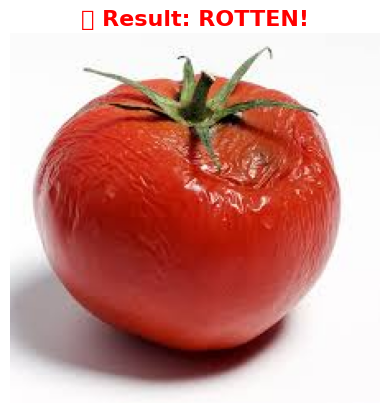

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('/content/cnn_model.keras')

def check_freshness(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print(f"❌ Error: Could not find image at {image_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, (100, 100))
    img_normalized = img_resized.astype('float32') / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)

    prediction = model.predict(img_batch)
    predicted_class = np.argmax(prediction)

    plt.imshow(img_rgb)
    plt.axis('off')

    if predicted_class == 0:
        plt.title("✔ Result: FRESH!", color='green', fontsize=16, fontweight='bold')
    else:
        plt.title("❌ Result: ROTTEN!", color='red', fontsize=16, fontweight='bold')

    plt.show()

check_freshness('/content/Tomato.jpg')